# Preparing Environment

In [1]:
# Install YOLOv8 (Ultralytics) dan library pendukung
!pip install ultralytics
!pip install albumentations opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import albumentations as A

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import ultralytics
import albumentations as A
import cv2
import sklearn

print("Ultralytics version:", ultralytics.__version__)
print("Albumentations version:", A.__version__)
print("OpenCV version:", cv2.__version__)
print("Scikit-learn version:", sklearn.__version__)

Ultralytics version: 8.4.48
Albumentations version: 2.0.8
OpenCV version: 4.13.0
Scikit-learn version: 1.6.1


In [4]:
import shutil

src = "/kaggle/input/datasets/maratunadhifahnayla/dataset"
dst = "/kaggle/working/warp_dataset"

shutil.copytree(src, dst, dirs_exist_ok=True)

print("Berhasil dicopy!")

Berhasil dicopy!


In [5]:
dataset_path = "/kaggle/working/warp_dataset/Warp-D"

In [6]:
import os
print(os.listdir(dataset_path))

['train', 'test', 'classes.txt']


In [7]:
print(os.listdir(dataset_path + "/train/images"))

['POSAD_1_12-Sep_14-46-22.jpg', 'POSAD_1_11-Sep_16-30-42.jpg', 'prepared_data_all_SPB-25-Jan_13-59-20.jpg', 'prepared_data_all_MGS-27-Oct_23-49-51.jpg', 'POSAD_1_12-Sep_15-46-25.jpg', 'prepared_data_all_MGS-05-Nov_02-00-16.jpg', 'Monitoring_photo2_04-Mar_02-19-34.jpg', 'prepared_data_all_MGS_19-Oct_19-18-01.jpg', 'POSAD_1_12-Sep_23-52-29.jpg', 'POSAD_1_12-Sep_16-11-14.jpg', 'prepared_data_all_MGS-27-Oct_23-41-09.jpg', 'Monitoring_photo2_04-Mar_00-52-37.jpg', 'Monitoring_photo_04-Mar_06-24-30.jpg', 'prepared_data_all_MGS_19-Oct_23-27-48.jpg', 'prepared_data_all_MGS_19-Oct_20-44-55.jpg', 'POSAD_1_13-Sep_04-45-06.jpg', 'prepared_data_all_MGS-05-Nov_04-21-03.jpg', 'Monitoring_photo_04-Mar_09-52-53.jpg', 'Monitoring_photo2_03-Mar_23-30-17.jpg', 'Monitoring_photo2_03-Mar_23-25-24.jpg', 'POSAD_1_11-Sep_14-17-17.jpg', 'prepared_data_all_MGS-28-Oct_01-27-22.jpg', 'POSAD_1_11-Sep_14-25-25.jpg', 'Monitoring_photo_04-Mar_06-20-42.jpg', 'Monitoring_photo2_04-Mar_00-15-09.jpg', 'POSAD_1_11-Sep_15-26

In [8]:
for root, dirs, files in os.walk(dataset_path):
    print(f"Folder: {root}")
    print(f"Subfolder: {dirs}")
    print(f"Jumlah file: {len(files)}")
    print("-" * 50)

Folder: /kaggle/working/warp_dataset/Warp-D
Subfolder: ['train', 'test']
Jumlah file: 1
--------------------------------------------------
Folder: /kaggle/working/warp_dataset/Warp-D/train
Subfolder: ['labels', 'images']
Jumlah file: 0
--------------------------------------------------
Folder: /kaggle/working/warp_dataset/Warp-D/train/labels
Subfolder: []
Jumlah file: 2452
--------------------------------------------------
Folder: /kaggle/working/warp_dataset/Warp-D/train/images
Subfolder: []
Jumlah file: 2452
--------------------------------------------------
Folder: /kaggle/working/warp_dataset/Warp-D/test
Subfolder: ['labels', 'images']
Jumlah file: 0
--------------------------------------------------
Folder: /kaggle/working/warp_dataset/Warp-D/test/labels
Subfolder: []
Jumlah file: 522
--------------------------------------------------
Folder: /kaggle/working/warp_dataset/Warp-D/test/images
Subfolder: []
Jumlah file: 522
--------------------------------------------------


# Data Preparation

In [9]:
import os

train_images = os.listdir(os.path.join(dataset_path, "train/images"))
train_labels = os.listdir(os.path.join(dataset_path, "train/labels"))

test_images = os.listdir(os.path.join(dataset_path, "test/images"))
test_labels = os.listdir(os.path.join(dataset_path, "test/labels"))

print("Train Images:", len(train_images))
print("Train Labels:", len(train_labels))
print("Test Images:", len(test_images))
print("Test Labels:", len(test_labels))

Train Images: 2452
Train Labels: 2452
Test Images: 522
Test Labels: 522


In [10]:
import os, shutil
from sklearn.model_selection import train_test_split

base_path     = dataset_path
train_img_path = os.path.join(base_path, "train/images")
train_lbl_path = os.path.join(base_path, "train/labels")
val_img_path   = os.path.join(base_path, "val/images")
val_lbl_path   = os.path.join(base_path, "val/labels")

os.makedirs(val_img_path, exist_ok=True)
os.makedirs(val_lbl_path, exist_ok=True)

# ✅ GUARD: hanya split kalau val masih kosong
if len(os.listdir(val_img_path)) == 0:
    images = [f for f in os.listdir(train_img_path) if f.endswith(('.jpg', '.png'))]
    train_files, val_files = train_test_split(images, test_size=0.2, random_state=42)

    for file in val_files:
        shutil.move(os.path.join(train_img_path, file), os.path.join(val_img_path, file))
        label_file = file.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(os.path.join(train_lbl_path, label_file)):
            shutil.move(os.path.join(train_lbl_path, label_file), os.path.join(val_lbl_path, label_file))

    print(f"Split selesai → Train: {len(train_files)}, Val: {len(val_files)}")
else:
    print(f"Val sudah ada ({len(os.listdir(val_img_path))} images), skip split.")

print(f"\nTrain: {len(os.listdir(train_img_path))} | Val: {len(os.listdir(val_img_path))}")

Split selesai → Train: 1961, Val: 491

Train: 1961 | Val: 491


In [11]:
classes = set()
import os

for file in os.listdir(dataset_path + "/train/labels"):
    with open(dataset_path + "/train/labels/" + file) as f:
        for line in f:
            parts = line.split()
            if len(parts) > 0:
                classes.add(int(parts[0]))

print(sorted(classes))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


In [12]:
def do_remap(label_folder):
    import os

    for filename in os.listdir(label_folder):

        if filename.endswith(".txt"):

            path = os.path.join(label_folder, filename)

            with open(path, 'r') as f:
                lines = f.readlines()

            new_lines = []

            for line in lines:

                parts = line.strip().split()

                if len(parts) < 5:
                    continue

                cls = int(parts[0])

                # bottle + glass
                if cls in [
                    0,1,2,3,4,5,6,7,
                    15,16,17,18,19,20,21,
                    23,24,
                    25,26,27
                ]:
                    new_cls = 2

                # cans
                elif cls == 8:
                    new_cls = 4

                # cardboard
                elif cls in [9,10]:
                    new_cls = 1

                # detergent
                elif cls in [11,12,13,22]:
                    new_cls = 3

                # canister
                elif cls == 14:
                    new_cls = 0

                else:
                    continue

                parts[0] = str(new_cls)

                new_lines.append(" ".join(parts) + "\n")

            with open(path, 'w') as f:
                f.writelines(new_lines)

In [13]:
do_remap(dataset_path + "/train/labels")
do_remap(dataset_path + "/val/labels")
do_remap(dataset_path + "/test/labels")

In [14]:
classes = set()

for file in os.listdir(dataset_path + "/train/labels"):
    with open(dataset_path + "/train/labels/" + file) as f:
        for line in f:
            parts = line.split()

            if len(parts) > 0:
                classes.add(int(parts[0]))

print(sorted(classes))

[0, 1, 2, 3, 4]


In [15]:
import yaml

data_yaml = {
    'path': dataset_path,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 5,
    'names': [
        'canister',
        'cardboard',
        'bottle',
        'detergent',
        'cans'
    ]
}

yaml_path = os.path.join(dataset_path, "data.yaml")
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("data.yaml berhasil dibuat di:", yaml_path)

data.yaml berhasil dibuat di: /kaggle/working/warp_dataset/Warp-D/data.yaml


Sample image: Robo_25-Mar_15-03-39.jpg


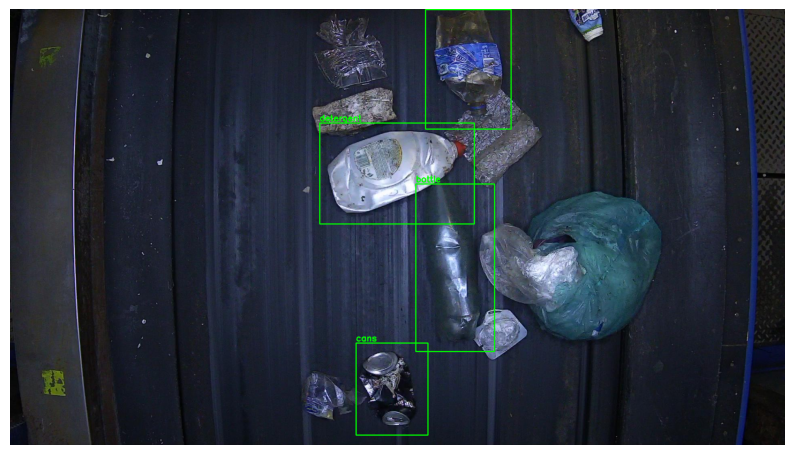

In [17]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Nama class hasil remap
class_names = [
    'canister',
    'cardboard',
    'bottle',
    'detergent',
    'cans'
]

# Fungsi visualisasi
def visualize_sample(image_path, label_path):
    # Baca gambar
    img = cv2.imread(image_path)
    # Ambil ukuran gambar
    h, w, _ = img.shape
    # Baca file label
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            # Format YOLO: class x_center y_center width height
            cls, x, y, bw, bh = map(float, parts)

            # Konversi koordinat YOLO → pixel
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)

            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)

            label = class_names[int(cls)]

            # Gambar bounding box
            cv2.rectangle(
                img,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # Tampilkan nama class
            cv2.putText(
                img,
                label,
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    # Tampilkan gambar
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# PILIH SAMPLE RANDOM

img_folder = dataset_path + "/train/images"
lbl_folder = dataset_path + "/train/labels"

# Ambil satu gambar random
sample = random.choice(os.listdir(img_folder))

# Path gambar
image_path = os.path.join(img_folder, sample)

# Path label pasangan
label_path = os.path.join(
    lbl_folder,
    sample.rsplit('.', 1)[0] + '.txt'
)

print("Sample image:", sample)

# Visualisasi
visualize_sample(image_path, label_path)

In [16]:
import os

train_imgs = len(os.listdir('/kaggle/working/warp_dataset/Warp-D/train/images'))
val_imgs   = len(os.listdir('/kaggle/working/warp_dataset/Warp-D/val/images'))
test_imgs  = len(os.listdir('/kaggle/working/warp_dataset/Warp-D/test/images'))

train_lbls = len(os.listdir('/kaggle/working/warp_dataset/Warp-D/train/labels'))
val_lbls   = len(os.listdir('/kaggle/working/warp_dataset/Warp-D/val/labels'))

print(f"Train  : {train_imgs} images, {train_lbls} labels")
print(f"Val    : {val_imgs} images, {val_lbls} labels")
print(f"Test   : {test_imgs} images")
print(f"Total  : {train_imgs + val_imgs + test_imgs} images")

Train  : 1961 images, 1961 labels
Val    : 491 images, 491 labels
Test   : 522 images
Total  : 2974 images


# Training Baseline

In [18]:
# ============ BASELINE FINAL (parameter yang terbukti) ============
import shutil, os
from ultralytics import YOLO

if os.path.exists('/kaggle/working/runs'):
    shutil.rmtree('/kaggle/working/runs')

model = YOLO('yolov8s.pt')

results_baseline = model.train(
    data='/kaggle/working/warp_dataset/Warp-D/data.yaml',
    epochs=50,
    imgsz=800,
    batch=16,

    seed=42,
    cache=True,

    device=0,

    name='baseline_yolov8s'
)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/warp_dataset/Warp-D/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

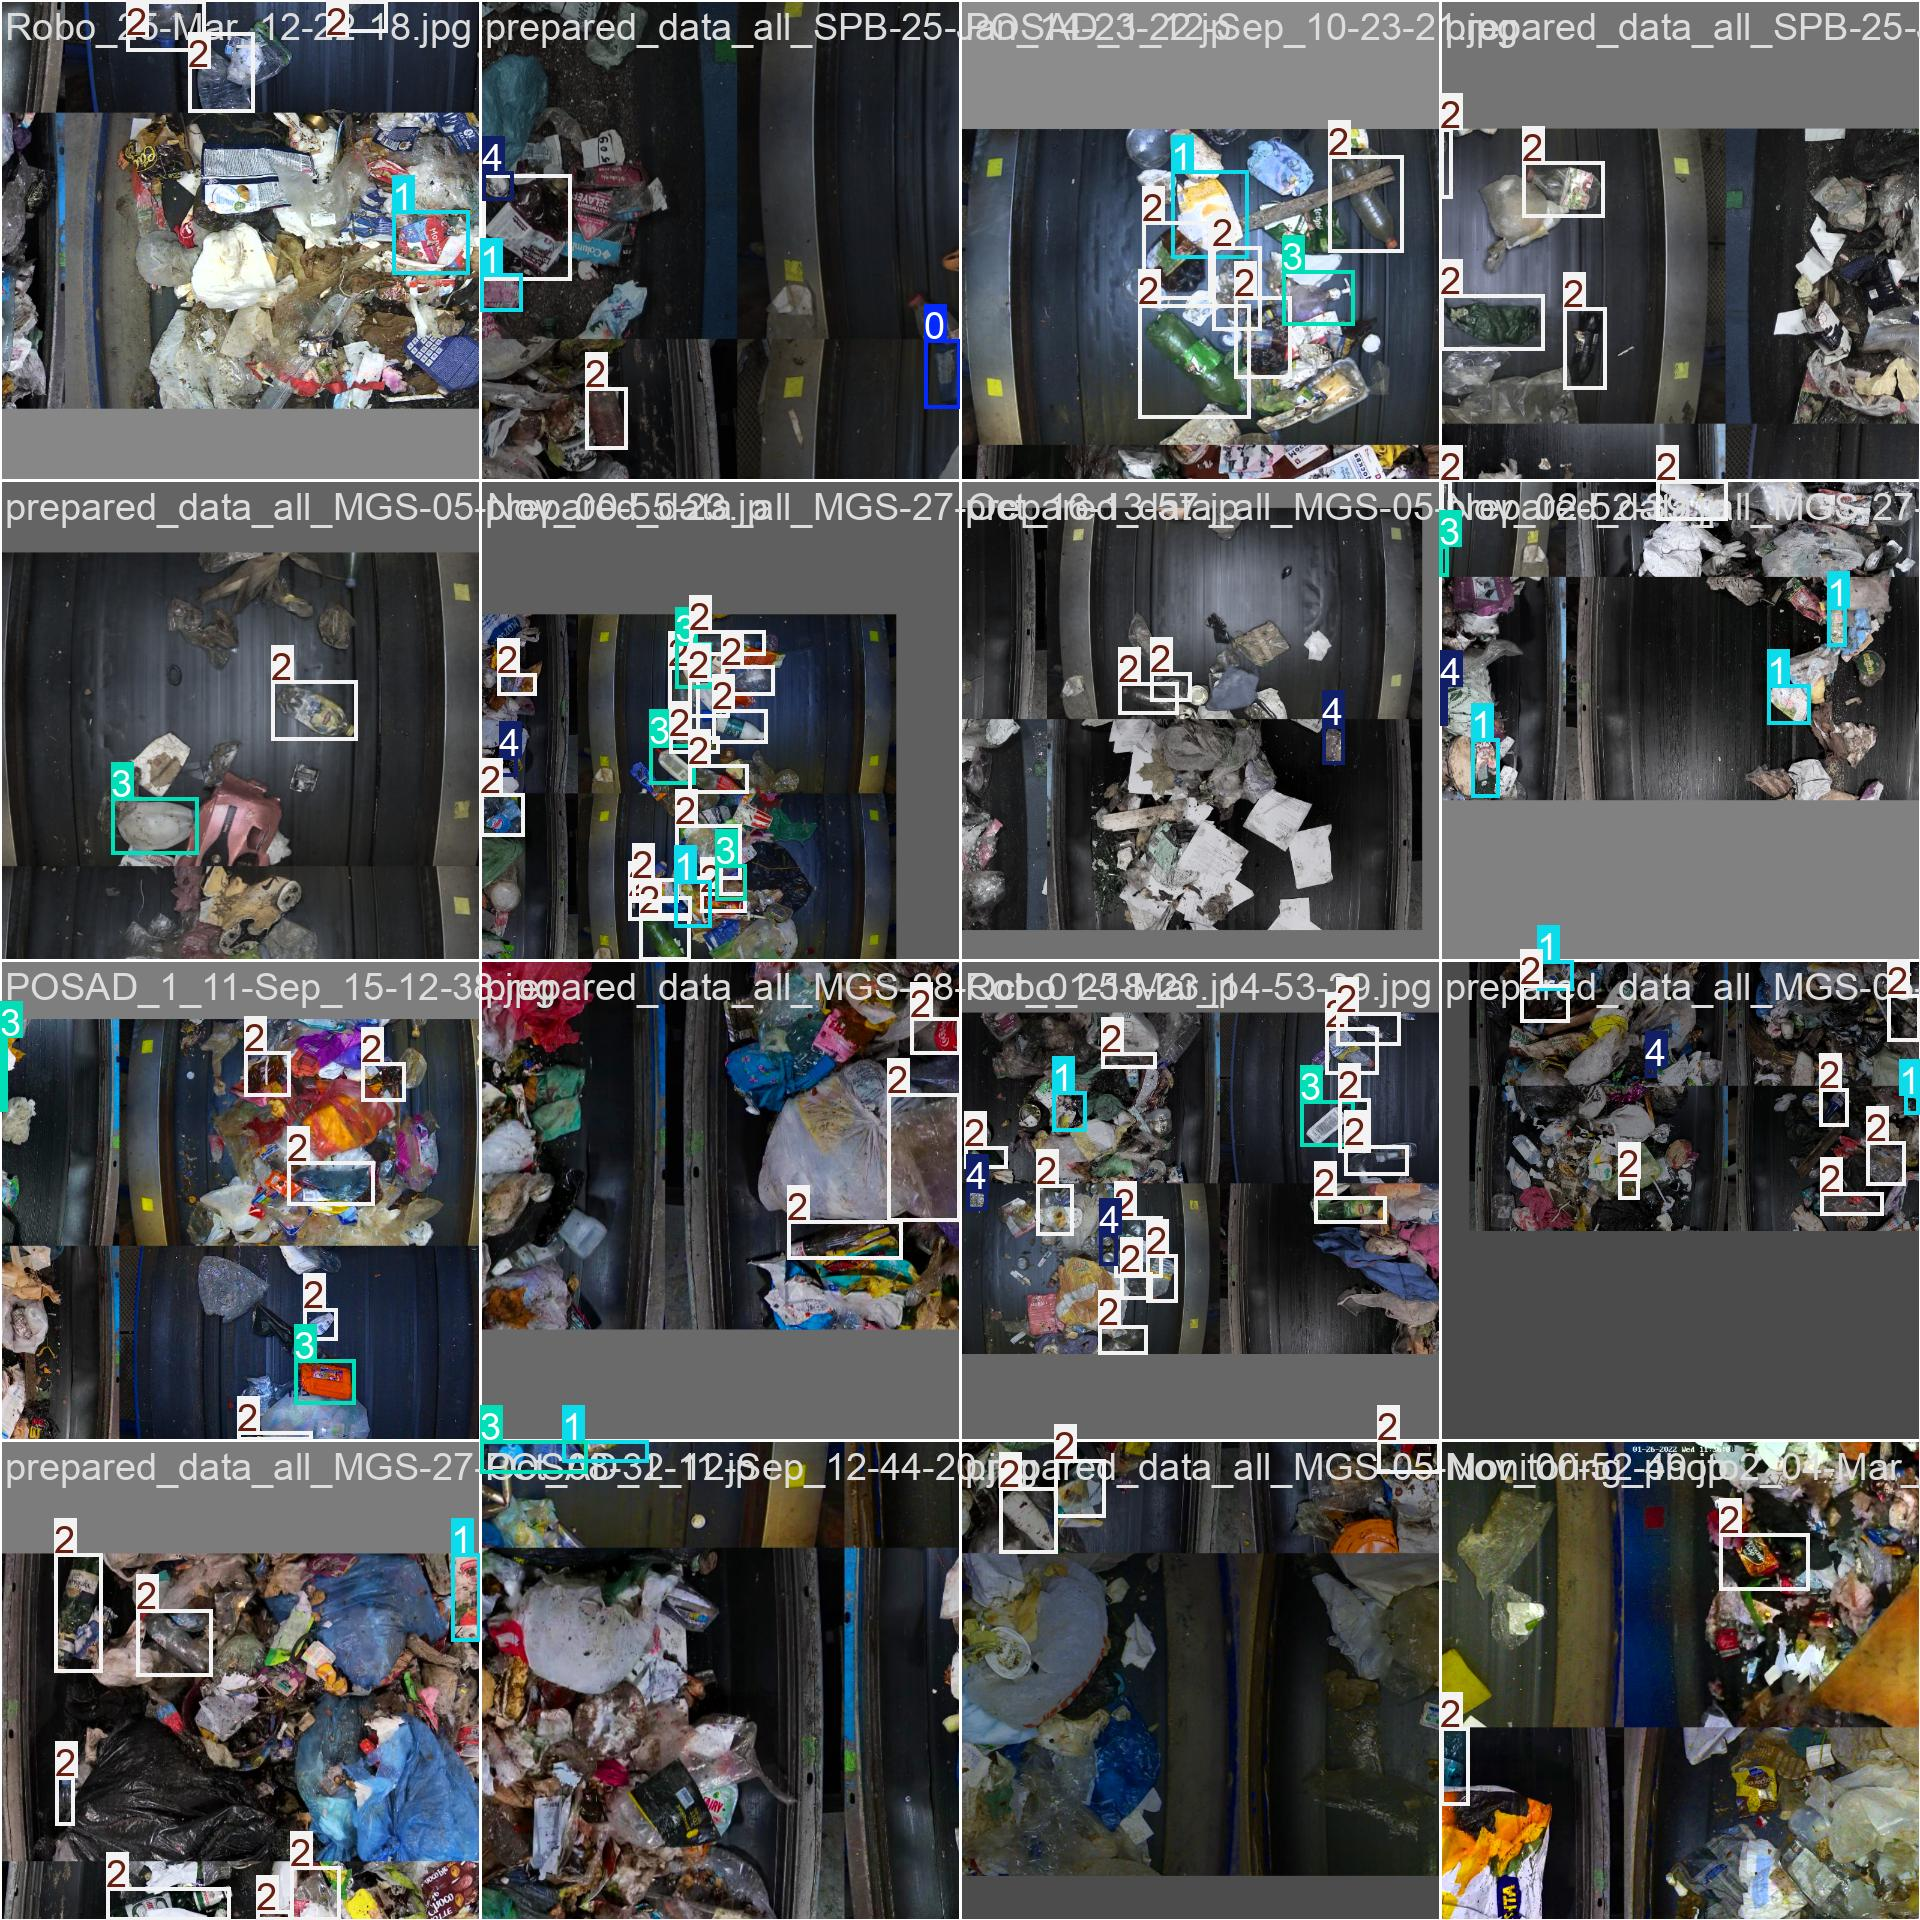

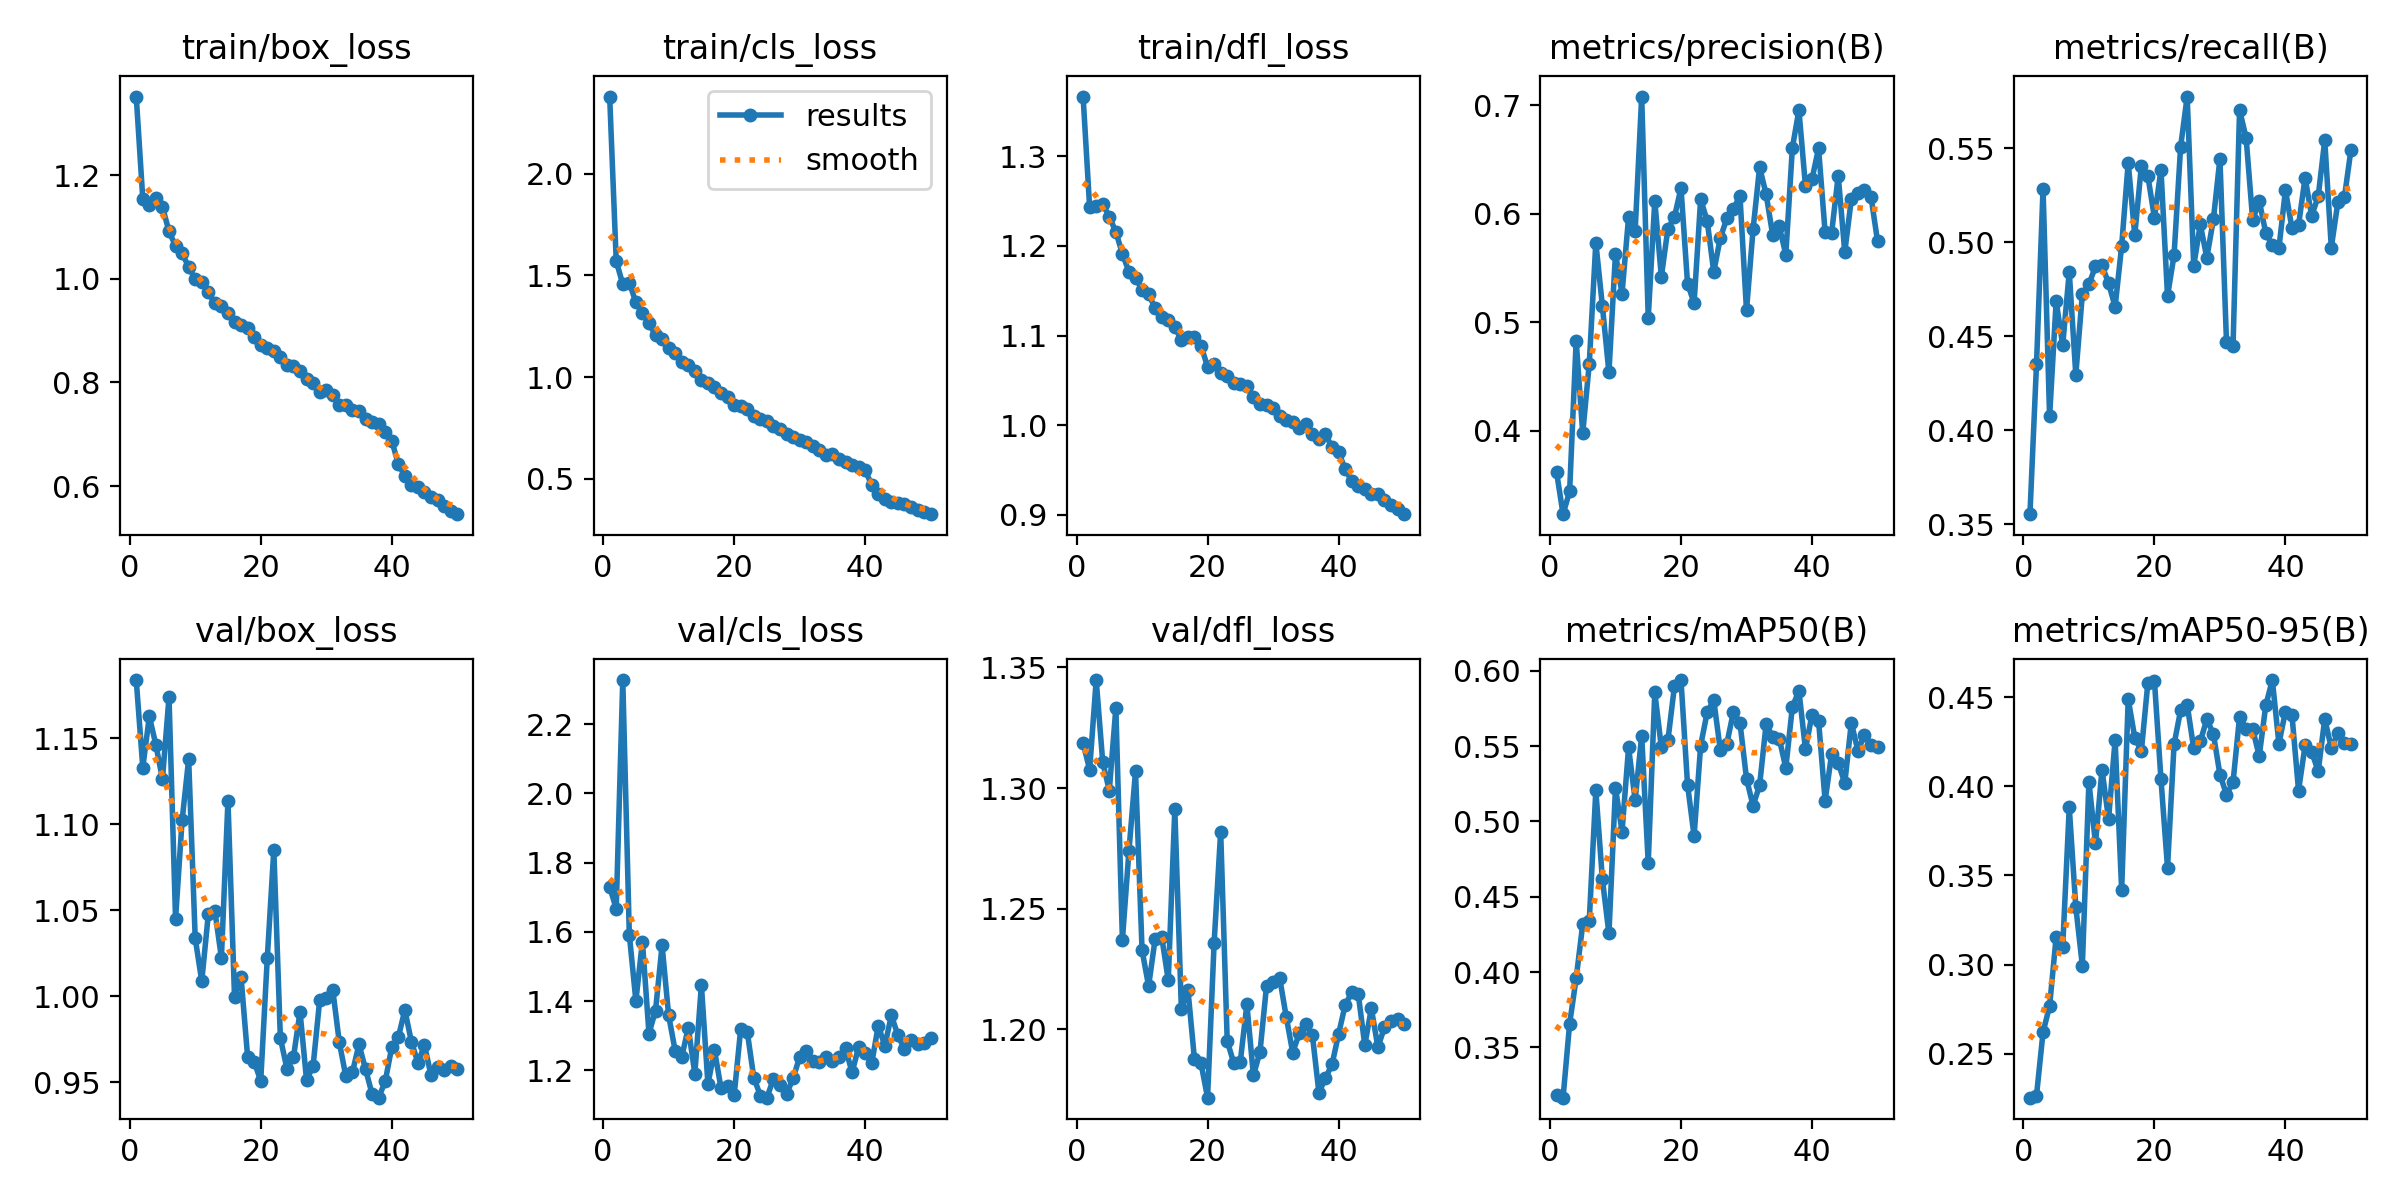

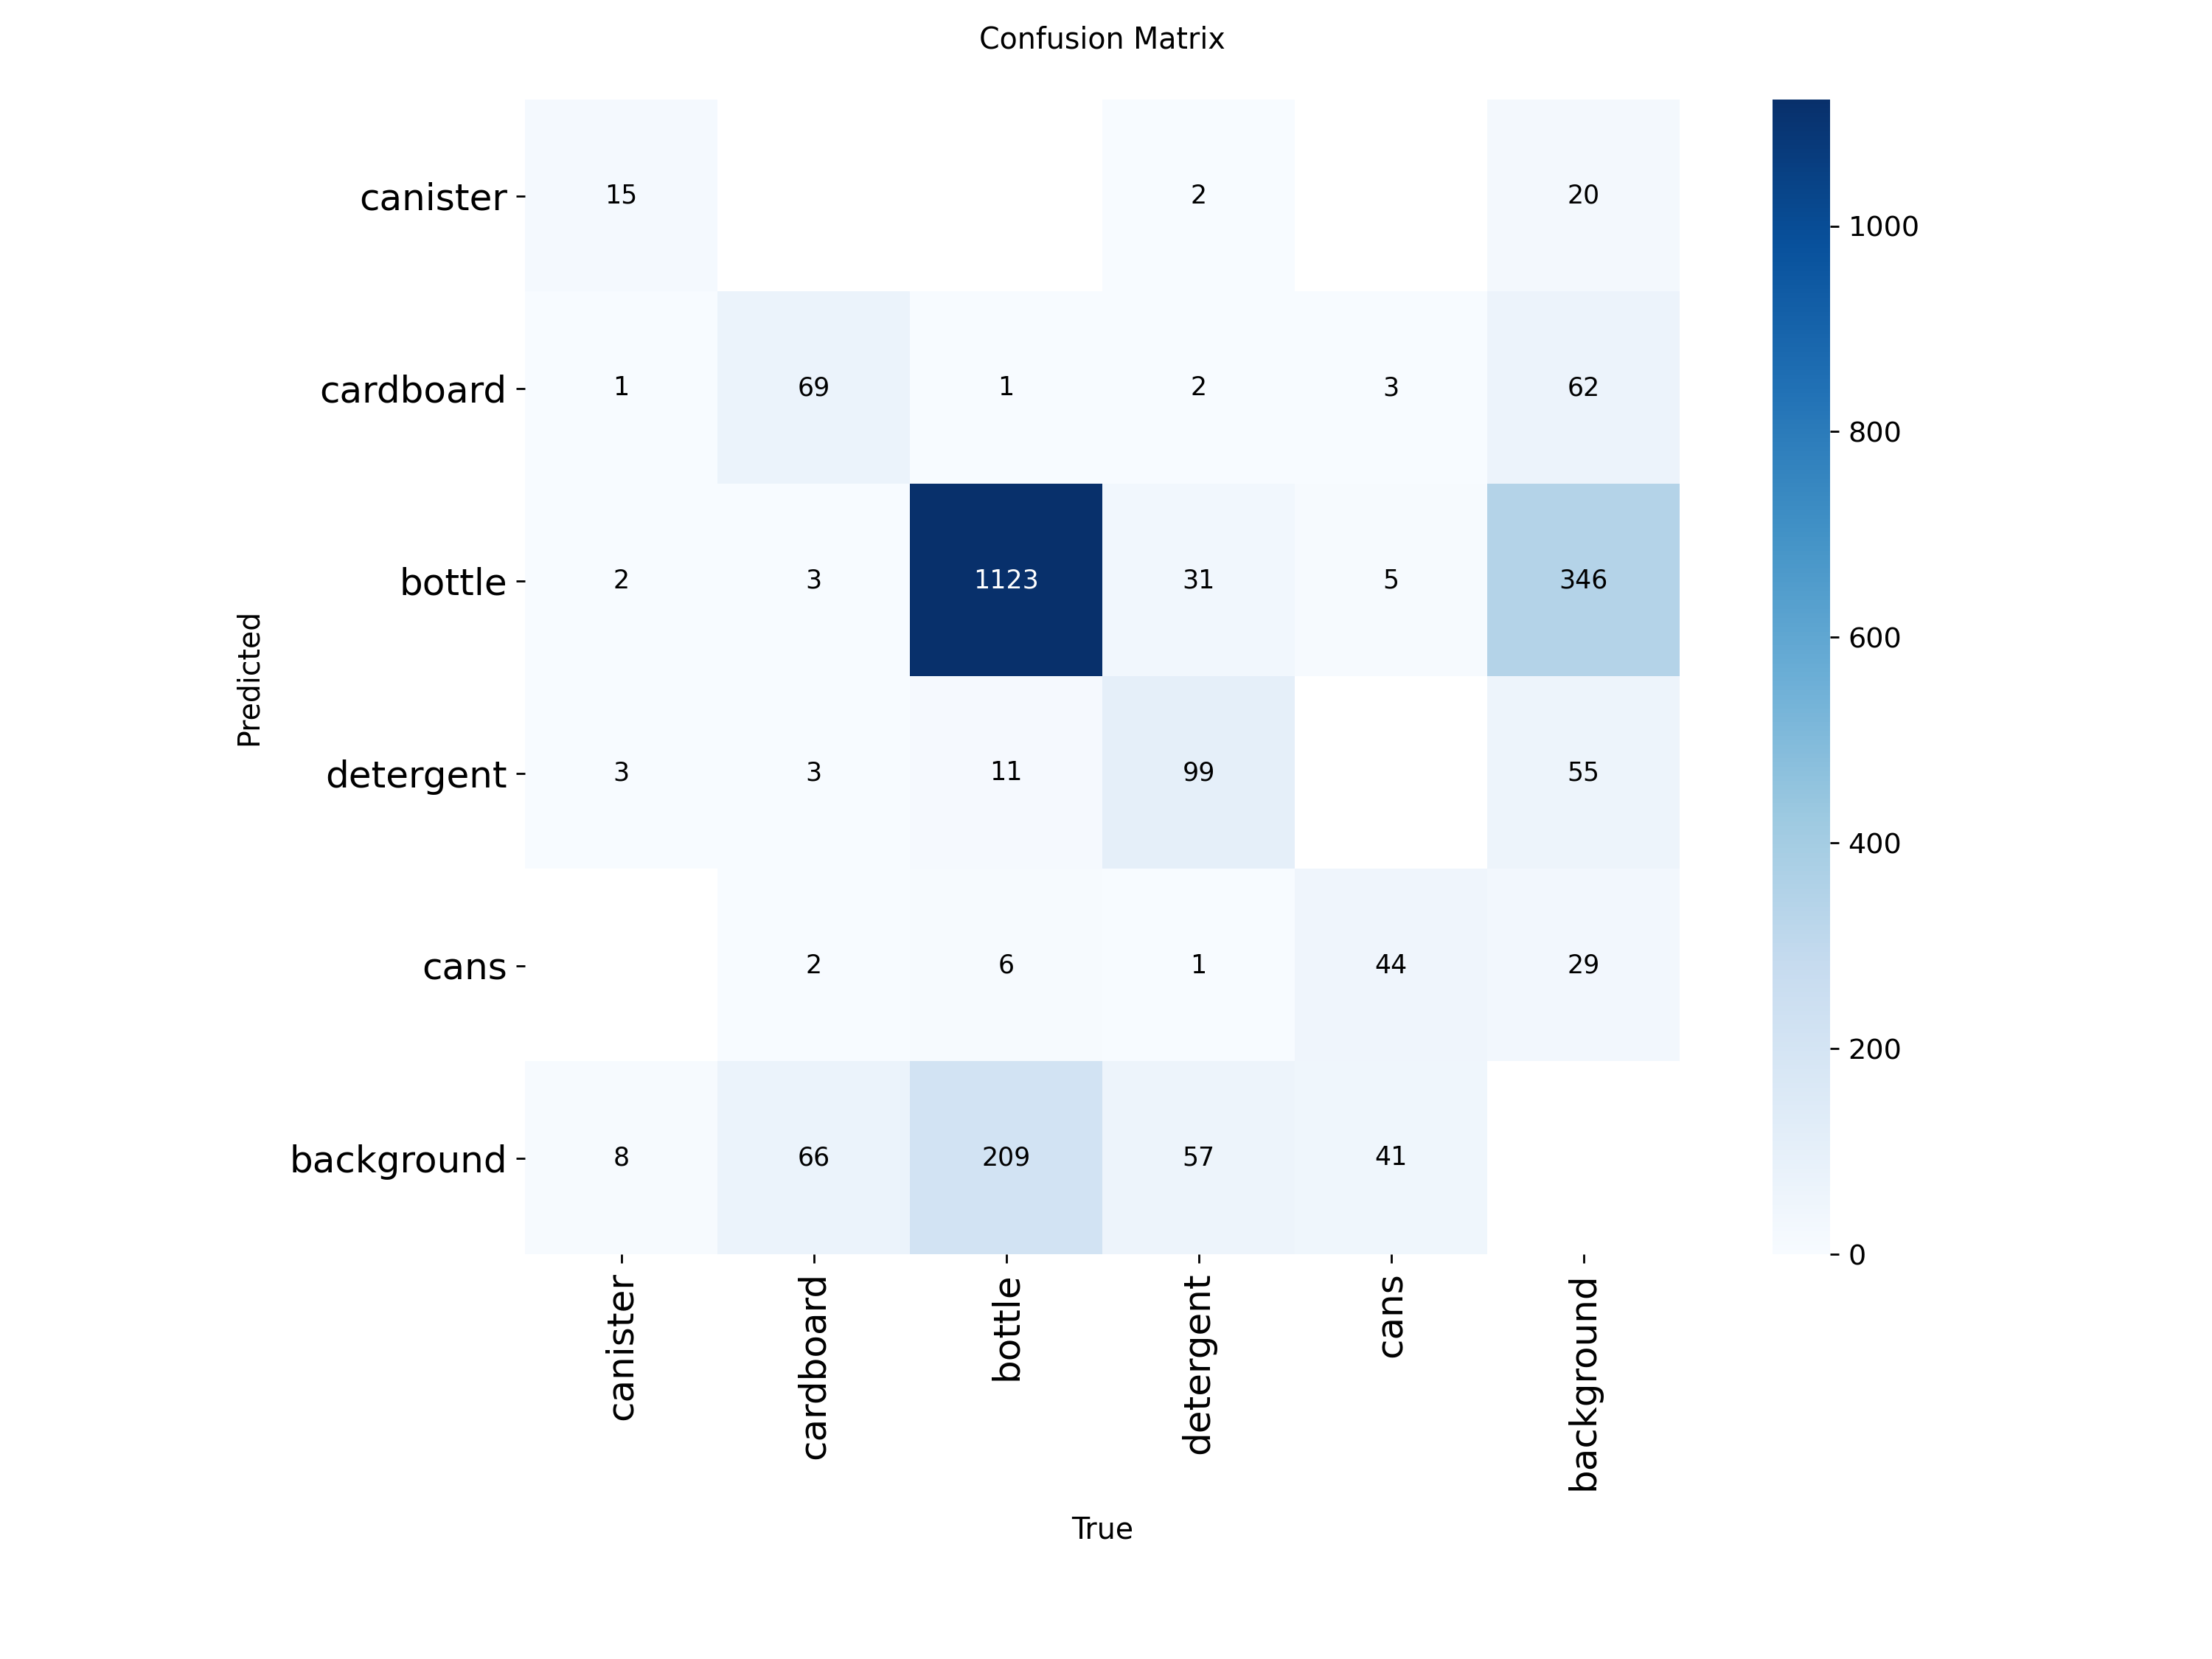

In [21]:
from IPython.display import Image, display

display(Image('/kaggle/working/runs/detect/baseline_yolov8s/train_batch0.jpg'))
display(Image('/kaggle/working/runs/detect/baseline_yolov8s/results.png'))
display(Image('/kaggle/working/runs/detect/baseline_yolov8s/confusion_matrix.png'))

# Training Augmentasi Pencahayaan

In [20]:
model2 = YOLO('yolov8s.pt')

results_aug = model2.train(
    data='/kaggle/working/warp_dataset/Warp-D/data.yaml',
    epochs=50,
    imgsz=800,
    batch=16,
    device=0,
    seed=42,

    hsv_v=0.6,   #Variasi kecerahan (terang&gelap) ekstrem
    hsv_s=0.5,   #Saturasi standar
    hsv_h=0.015, #Hue standar

    name='augmented_lighting',
    exist_ok=False,
    plots=True
)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/warp_dataset/Warp-D/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.6, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=augmented_lighting-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

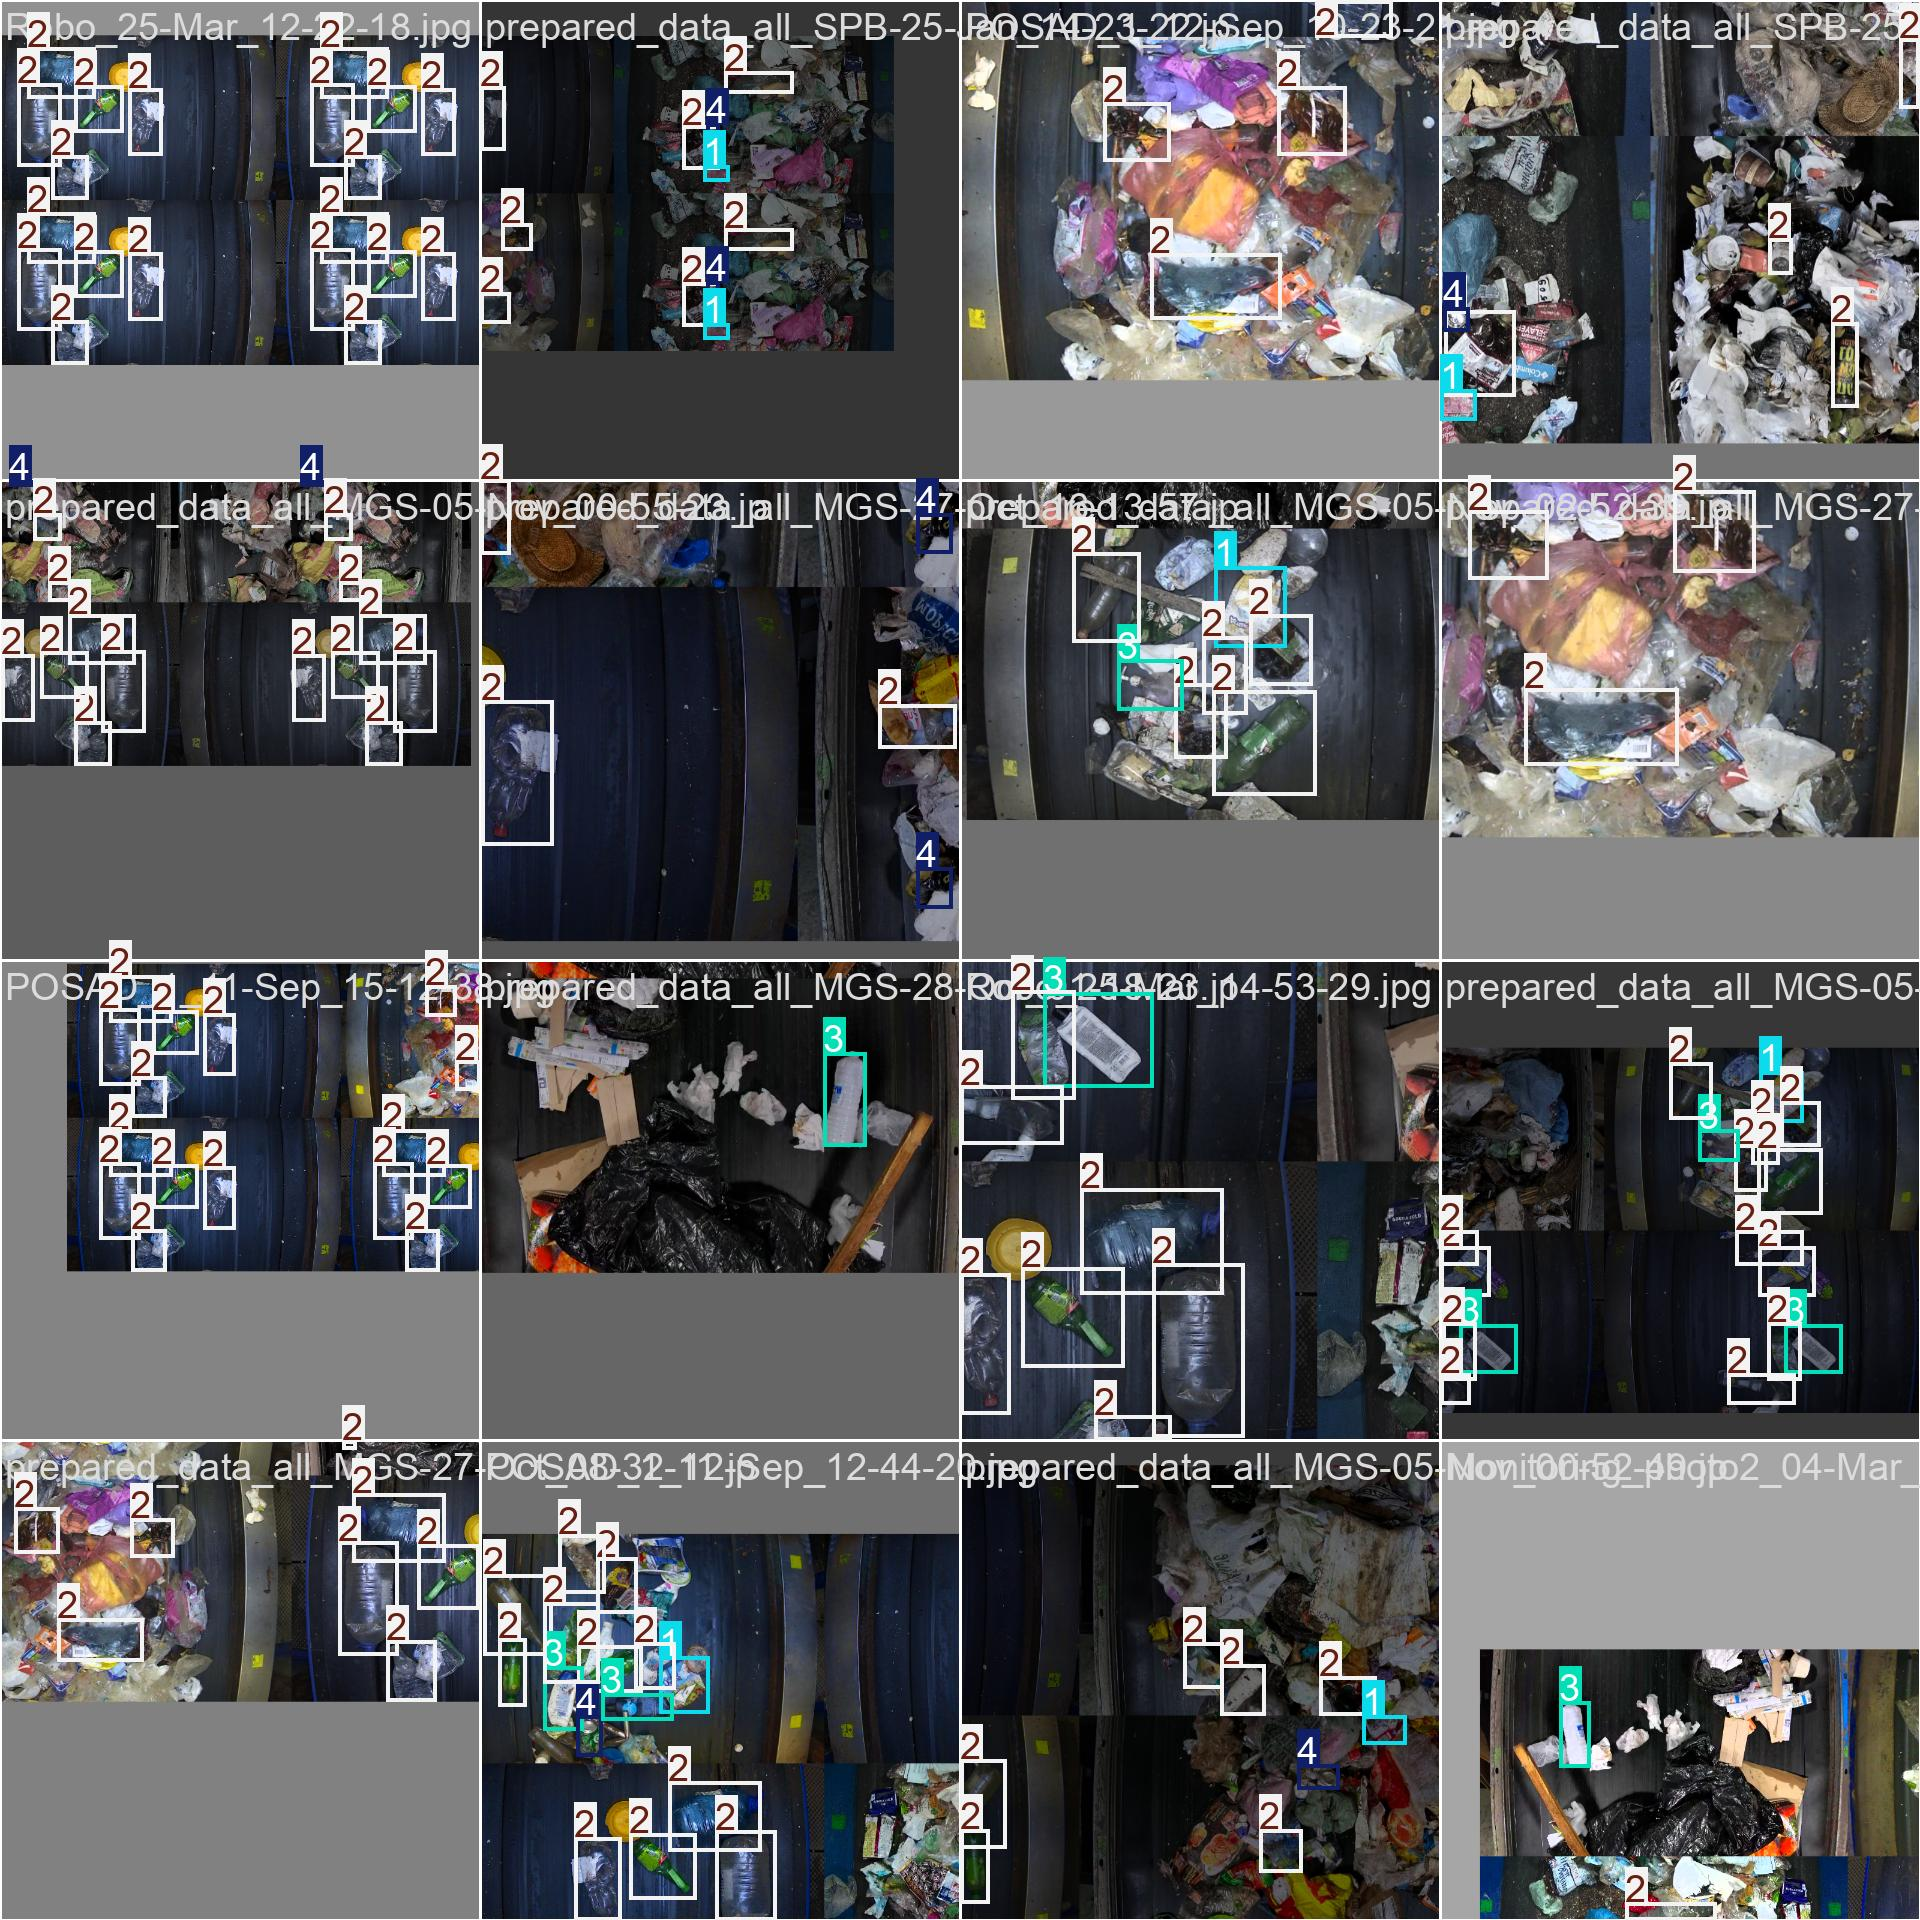

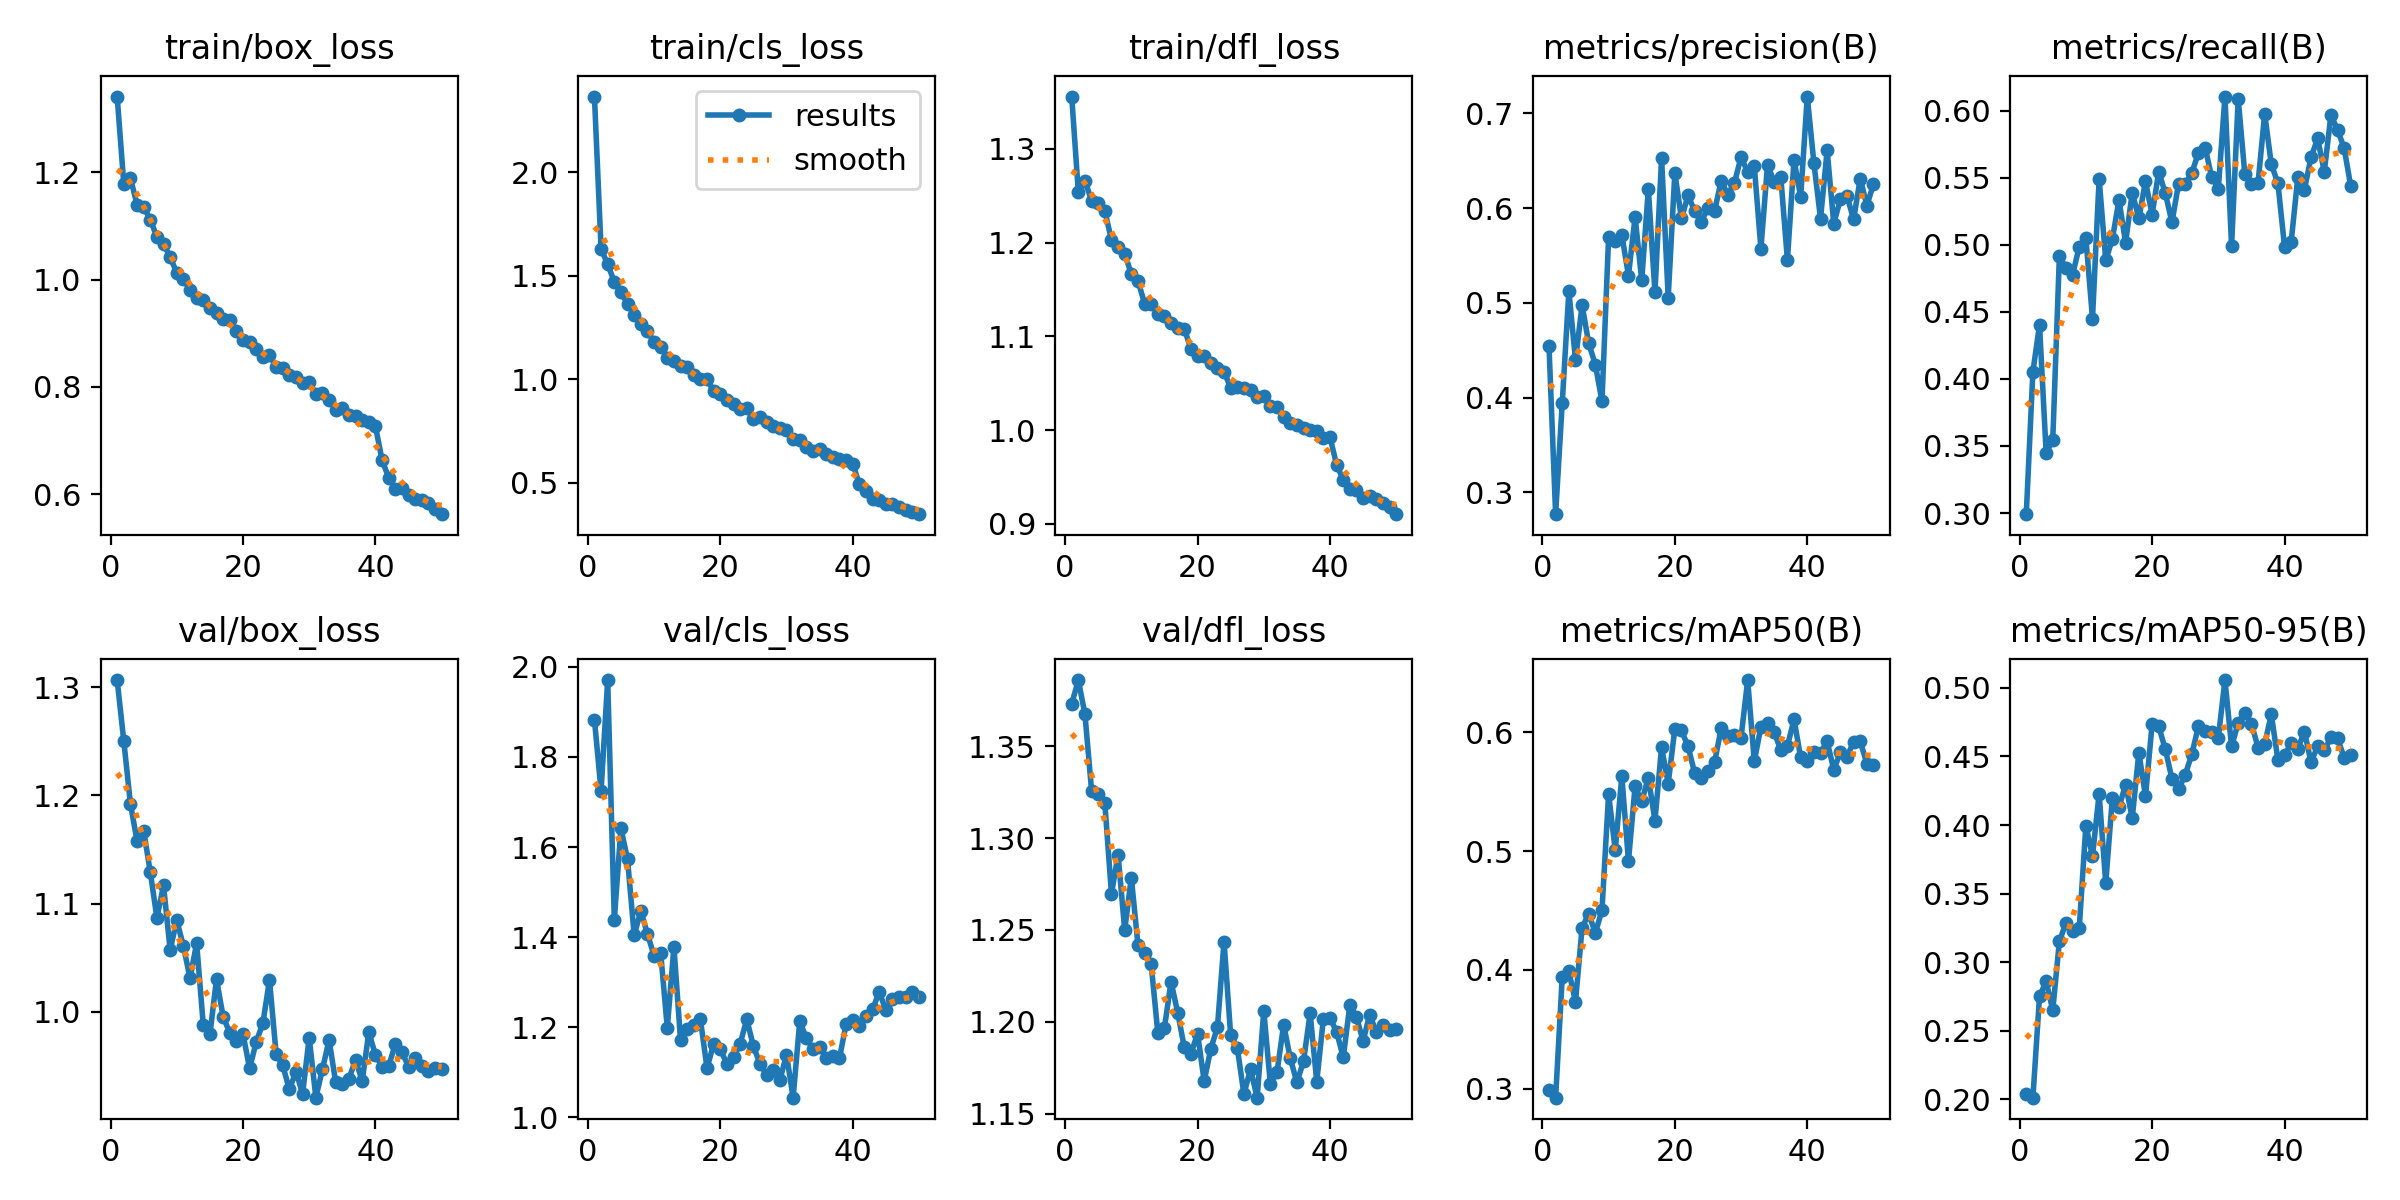

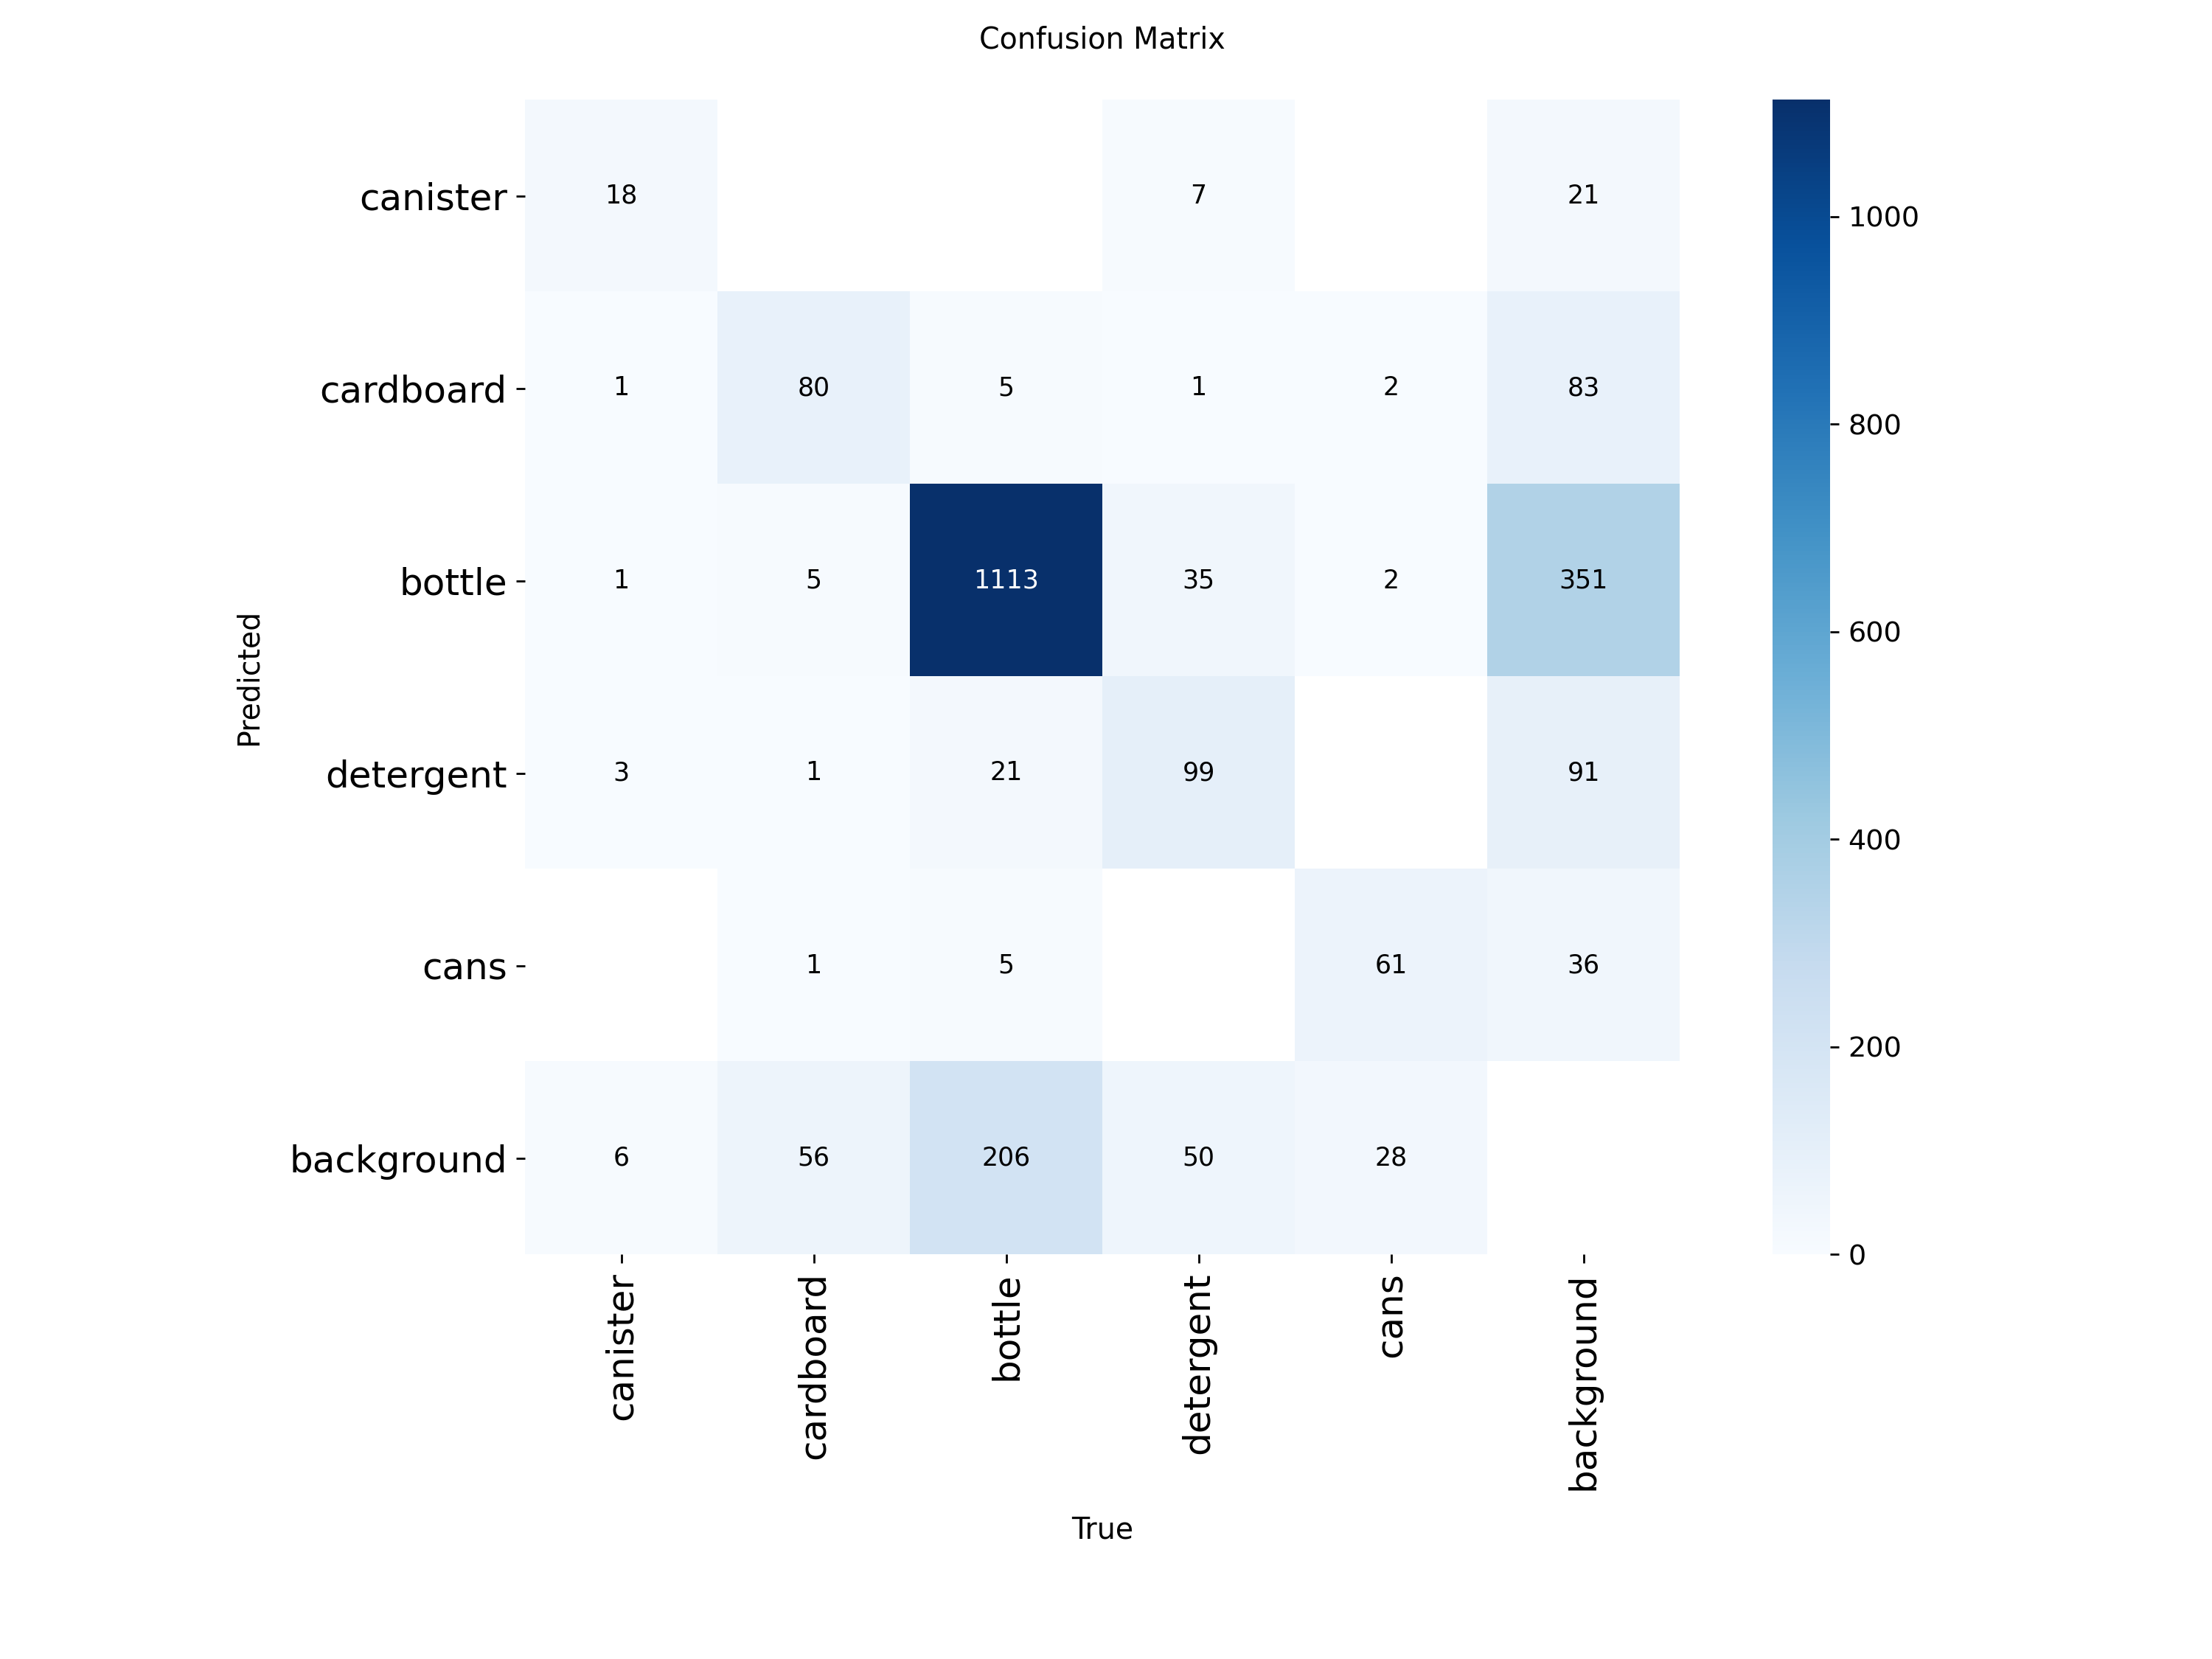

In [22]:
from IPython.display import Image, display

display(Image('/kaggle/working/runs/detect/augmented_lighting-2/train_batch0.jpg'))
display(Image('/kaggle/working/runs/detect/augmented_lighting-2/results.png'))
display(Image('/kaggle/working/runs/detect/augmented_lighting-2/confusion_matrix.png'))